# Input Overview (for PPT screenshots)

This notebook generates **screenshot-friendly tables** describing:
1) the **data universe & date ranges** (total + train/val/test)
2) the **feature sets** (groups + number of features used)

No figures are saved to disk; output is displayed inline for screenshots.

Default: **TAG=083, MODE=live**.

In [69]:
import pandas as pd
from pathlib import Path

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 140)

ROOT = Path(r'C:/Users/user/Downloads/Moltbot/HKU-FYP/fyp_finance_ml_v2')
OUT = ROOT / 'outputs'

TAG = '084'
MODE = 'live'

metrics_path = OUT / 'metrics' / f'{TAG}_{MODE}_metrics.csv'
dq_path = OUT / 'tables' / f'{TAG}_{MODE}_data_quality.csv'
summary_path = OUT / 'metrics' / f'{TAG}_{MODE}_backtest_summary.csv' # 请检查文件夹名是否为 'backtest'

assert metrics_path.exists(), metrics_path
assert dq_path.exists(), dq_path
print('OK:', metrics_path.name, dq_path.name)

OK: 084_live_metrics.csv 084_live_data_quality.csv


## 1) Universe & date ranges (Input summary)
We pull this from:
- `data_quality.csv` (ticker count + per-ticker coverage)
- `metrics.csv` (train/val/test start/end used for evaluation)

In [70]:
dq = pd.read_csv(dq_path)
metrics = pd.read_csv(metrics_path)
summary = pd.read_csv(summary_path)

dq.head()

,ticker,row_count,start_date,end_date,close_na_ratio
0,AAPL,2514,2016-01-04,2025-12-31,0.000000
1,ABBV,2514,2016-01-04,2025-12-31,0.000000
2,ABNB,2514,2016-01-04,2025-12-31,0.494829
3,ABT,2514,2016-01-04,2025-12-31,0.000000
4,ACN,2514,2016-01-04,2025-12-31,0.000000


In [3]:
# Basic universe counts
n_tickers = dq['ticker'].nunique() if 'ticker' in dq.columns else None
n_rows_total = dq['row_count'].sum() if 'row_count' in dq.columns else None
n_tickers, n_rows_total

(164, np.int64(412296))

In [4]:
# Infer overall (approx) date range from dq, if it has per-ticker start/end columns
def _to_dt(s):
    return pd.to_datetime(s, errors='coerce')

overall_start = None
overall_end = None

for c in dq.columns:
    lc = c.lower()
    if overall_start is None and 'start' in lc:
        overall_start = _to_dt(dq[c]).min()
    if overall_end is None and 'end' in lc:
        overall_end = _to_dt(dq[c]).max()

overall_start, overall_end

(Timestamp('2016-01-04 00:00:00'), Timestamp('2025-12-31 00:00:00'))

In [5]:
# Train/Val/Test date ranges from metrics.csv (consistent within a run)
row0 = metrics.iloc[0]

split_table = pd.DataFrame([
    {'Item': 'Tickers Selected', 'Value': n_tickers},
    {'Item': 'Total rows (sum over tickers)', 'Value': int(n_rows_total) if n_rows_total is not None else None},
    {'Item': 'Total date range (approx start)', 'Value': str(overall_start.date()) if overall_start is not None else 'N/A'},
    {'Item': 'Total date range (approx end)', 'Value': str(overall_end.date()) if overall_end is not None else 'N/A'},
    {'Item': 'Train period', 'Value': '{} to {}'.format(row0['train_start'], row0['train_end'])},
    {'Item': 'Validation period', 'Value': '{} to {}'.format(row0['val_start'], row0['val_end'])},
    {'Item': 'Test period', 'Value': '{} to {}'.format(row0['test_start'], row0['test_end'])},
])
split_table

,Item,Value
0,Tickers Selected,164
1,Total rows (sum over tickers),412296
2,Total date range (approx start),2016-01-04
3,Total date range (approx end),2025-12-31
4,Train period,2016-01-04 to 2022-12-27
5,Validation period,2022-12-28 to 2024-06-28
6,Test period,2024-07-01 to 2025-12-30


In [6]:
import pandas as pd

# 配置美化 (在截图前运行)
def highlight_max(s):
    return ['background-color: #f0f7ff' if v else '' for v in s]

# 1. 基础信息汇总
n_tickers = dq['ticker'].nunique()
total_points = dq['row_count'].sum()
avg_completeness = (1 - dq['close_na_ratio'].mean()) * 100

row0 = metrics.iloc[0]
info_df = pd.DataFrame([
    ["Ticker Universe", f"{n_tickers} Symbols (US Equities)", "Broad market coverage"],
    ["Total Observations", f"{total_points:,} Rows", "High-density time series"],
    ["Data Completeness", f"{avg_completeness:.2f}%", "Minimal missing values"],
    ["Training Period", f"{row0['train_start']} ~ {row0['train_end']}", "In-sample optimization"],
    ["Validation Period", f"{row0['val_start']} ~ {row0['val_end']}", "Hyperparameter tuning"],
    ["Out-of-Sample (Live)", f"{row0['test_start']} ~ {row0['test_end']}", "True blind testing"]
], columns=["Dimension", "Value", "Notes"])

# 展示表格
print("Data Infrastructure Overview")
info_df.style.set_properties(**{'text-align': 'left', 'font-family': 'Arial'})\
    .set_table_styles([{'selector': 'th', 'props': [('background-color', '#2c3e50'), ('color', 'white')]}])

Data Infrastructure Overview


,Dimension,Value,Notes
0,Ticker Universe,164 Symbols (US Equities),Broad market coverage
1,Total Observations,"412,296 Rows",High-density time series
2,Data Completeness,95.89%,Minimal missing values
3,Training Period,2016-01-04 ~ 2022-12-27,In-sample optimization
4,Validation Period,2022-12-28 ~ 2024-06-28,Hyperparameter tuning
5,Out-of-Sample (Live),2024-07-01 ~ 2025-12-30,True blind testing


In [7]:
import pandas as pd

# 1. 定义你的特征字典 (Feature Library)
feature_lib = {
    "Momentum": [
        "ret_1", "ret_3", "ret_5", "ret_10", "ret_21", "ret_63",
        "ma_ratio_5_20", "ma_ratio_20_50", "ma_ratio_50_200",
        "price_to_ma20", "price_to_ma50", "rsi_14",
        "gap_ret_1", "intraday_ret_1"
    ],
    "Reversal": [
        "reversal_1_5", "reversal_1_10", "rsi_2",
        "dist_to_20d_high", "dist_to_20d_low",
        "dist_to_5d_high", "dist_to_5d_low"
    ],
    "Volatility": [
        "vol_5", "vol_21", "vol_63", "downside_vol_21",
        "intraday_range", "atrp_14", "mom_21_voladj"
    ],
    "Liquidity": [
        "volume_chg_1", "volume_ratio_20", "dollar_volume_ratio_20",
        "amihud_approx", "amihud_5", "volume_vol_20"
    ],
    "Cross-Sectional": [
        "rel_ret_1", "rel_ret_5", "beta_60", "alpha_ret_1", "alpha_ret_5",
        "mom_rank_pct", "alpha_mom_rank_pct", "vol_rank_pct", "liq_rank_pct"
    ],
    "Macro": [
        "spy_ret_1", "spy_ret_5", "spy_vol_21", "spy_ma_ratio_20_50",
        "spy_drawdown_252", "qqq_ret_1", "qqq_ret_5", "vix_chg_1",
        "vix_level", "vix_z_21", "tnx_chg_1", "tnx_chg_5", "tnx_level"
    ]
}

# 2. 转换为展示用的 DataFrame
# 每行显示 4-5 个特征，方便截图阅读
def wrap_features(feat_list, n=5):
    return [", ".join(feat_list[i:i+n]) for i in range(0, len(feat_list), n)]

display_data = []
for category, features in feature_lib.items():
    wrapped = "\n".join(wrap_features(features))
    display_data.append({
        "Category": category,
        "Factor Count": len(features),
        "Key Indicators (Glimpse)": wrapped
    })

lib_df = pd.DataFrame(display_data)

# 3. 使用 Pandas Style 美化展示
print("Factor Library & Feature Engineering Architecture")
lib_df.style.set_properties(**{
    'text-align': 'left',
    'white-space': 'pre-wrap', # 关键：保持换行
    'font-size': '12px'
}).set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#2471a3'), ('color', 'white'), ('font-weight', 'bold')]},
    {'selector': 'td', 'props': [('border', '1px solid #dee2e6')]}
]).hide(axis='index')

Factor Library & Feature Engineering Architecture


Category,Factor Count,Key Indicators (Glimpse)
Momentum,14,"ret_1, ret_3, ret_5, ret_10, ret_21 ret_63, ma_ratio_5_20, ma_ratio_20_50, ma_ratio_50_200, price_to_ma20 price_to_ma50, rsi_14, gap_ret_1, intraday_ret_1"
Reversal,7,"reversal_1_5, reversal_1_10, rsi_2, dist_to_20d_high, dist_to_20d_low dist_to_5d_high, dist_to_5d_low"
Volatility,7,"vol_5, vol_21, vol_63, downside_vol_21, intraday_range atrp_14, mom_21_voladj"
Liquidity,6,"volume_chg_1, volume_ratio_20, dollar_volume_ratio_20, amihud_approx, amihud_5 volume_vol_20"
Cross-Sectional,9,"rel_ret_1, rel_ret_5, beta_60, alpha_ret_1, alpha_ret_5 mom_rank_pct, alpha_mom_rank_pct, vol_rank_pct, liq_rank_pct"
Macro,13,"spy_ret_1, spy_ret_5, spy_vol_21, spy_ma_ratio_20_50, spy_drawdown_252 qqq_ret_1, qqq_ret_5, vix_chg_1, vix_level, vix_z_21 tnx_chg_1, tnx_chg_5, tnx_level"


In [15]:
import pandas as pd
# 1. 明确关联键：除了 feature_set，通常还需要 horizon_days 和 model 才能唯一确定一行
join_keys = ['feature_set', 'horizon_days', 'model']

# 2. 准备列：确保 join_keys 都在筛选列表中
perf_cols = join_keys + ['balanced_accuracy', 'rank_ic', 'icir']
bt_cols = join_keys + ['annualized_return', 'sharpe', 'max_drawdown', 'win_rate']

# 3. 数据清洗：在合并前先去重或筛选 (例如：我们只想对比 horizon_days 为 1 的表现)
# 如果你想看所有的，可以去掉这个 .query
metrics_sub = metrics[perf_cols].drop_duplicates()
summary_sub = summary[bt_cols].drop_duplicates()

# 4. 执行合并 (使用多个 Key 避免行爆炸)
final_matrix = pd.merge(metrics_sub, summary_sub, on=join_keys, how='inner')

# 5. 可选：如果你有多种 model，这里可以再筛选一下你想展示的那一个
# final_matrix = final_matrix[final_matrix['model'] == 'logistic_regression']

# 6. 格式化字典
format_dict = {
    'balanced_accuracy': '{:.2%}',
    'rank_ic': '{:.3f}',
    'icir': '{:.2f}',
    'annualized_return': '{:.2%}',
    'sharpe': '{:.2f}',
    'max_drawdown': '{:.2%}',
    'win_rate': '{:.2%}'
}

print(f"Strategic Performance Scorecard (Out-of-Sample)")
print(f"Note: Combined on {join_keys}")

# 7. 渲染美化
# final_matrix.head(10).style.format(format_dict)\
#     .set_properties(**{'font-weight': 'bold', 'color': 'black'}, subset=['sharpe'])\
#     .set_table_styles([
#         {'selector': 'th', 'props': [('background-color', '#1e8449'), ('color', 'white'), ('text-align', 'center')]},
#         {'selector': 'td', 'props': [('text-align', 'center')]}
#     ]).hide(axis='index')

final_matrix.sort_values(by=["sharpe"], ascending=False)\
    .style.format(format_dict)\
    .set_properties(**{'font-weight': 'bold', 'color': 'black'}, subset=['sharpe'])\
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#1e8449'), ('color', 'white'), ('text-align', 'center')]},
        {'selector': 'td', 'props': [('text-align', 'center')]}
    ]).hide(axis='index')

Strategic Performance Scorecard (Out-of-Sample)
Note: Combined on ['feature_set', 'horizon_days', 'model']


feature_set,horizon_days,model,balanced_accuracy,rank_ic,icir,annualized_return,sharpe,max_drawdown,win_rate
F1_momentum,3,random_forest,50.87%,0.007,0.05,19.06%,1.18,-20.55%,54.96%
F2_momentum_reversal,3,random_forest,50.94%,0.007,0.04,15.72%,0.98,-22.65%,52.82%
F1_momentum,3,random_forest,50.87%,0.007,0.05,13.42%,0.87,-20.51%,56.15%
F4_plus_cross_sectional,1,logistic_regression,50.11%,0.009,0.04,22.60%,0.85,-23.66%,53.07%
F2_momentum_reversal,3,random_forest,50.94%,0.007,0.04,11.28%,0.74,-22.48%,54.28%
F1_momentum,3,xgboost,50.50%,0.003,0.03,7.46%,0.50,-27.36%,50.40%
F3_plus_risk_liquidity,3,random_forest,50.46%,0.011,0.07,6.57%,0.47,-19.35%,49.06%
F3_plus_risk_liquidity,3,xgboost,50.51%,0.005,0.04,6.23%,0.44,-26.28%,51.74%
F2_momentum_reversal,3,xgboost,50.39%,-0.000,-0.00,5.83%,0.40,-30.16%,48.79%
F5_full_finance_no_fundamental,1,logistic_regression,50.27%,0.007,0.03,5.34%,0.32,-18.89%,48.94%


### Optional: coverage / missingness summary across tickers
Useful if asked why the universe is 164 (data availability filter).

In [16]:
cols = [c for c in ['row_count','close_na_ratio','open_na_ratio','volume_na_ratio'] if c in dq.columns]
dq[cols].describe().T if cols else 'No standard quality columns found in dq file.'

,count,mean,std,min,25%,50%,75%,max
row_count,164.0,2514.000000,0.000000,2514.0,2514.0,2514.0,2514.0,2514.0
close_na_ratio,164.0,0.041104,0.159171,0.0,0.0,0.0,0.0,1.0


C:\Users\user\AppData\Local\Temp\ipykernel_26496\3267902112.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_acc, x='Metric', y='Score', palette='Set3')


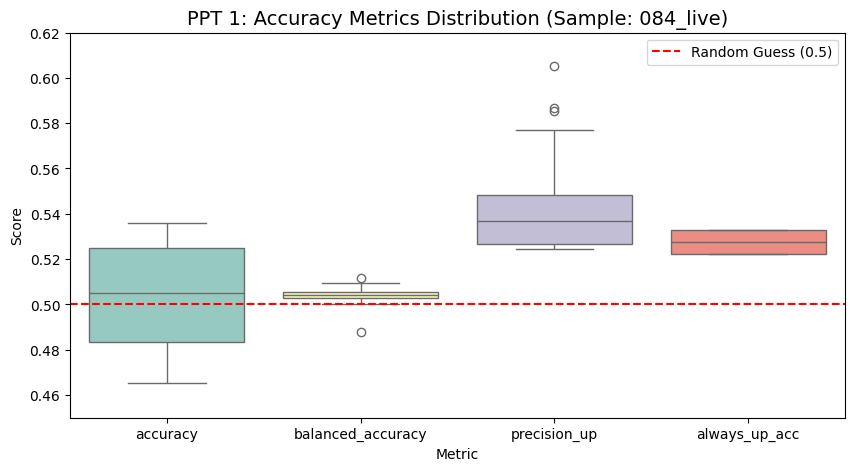

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

# 准备准确率对比数据
acc_metrics = ['accuracy', 'balanced_accuracy', 'precision_up', 'always_up_acc']
df_acc = metrics.melt(id_vars=['model', 'horizon_days'], value_vars=acc_metrics, var_name='Metric', value_name='Score')

plt.figure(figsize=(10, 5))
sns.boxplot(data=df_acc, x='Metric', y='Score', palette='Set3')
plt.axhline(0.5, color='red', linestyle='--', label='Random Guess (0.5)')
plt.title("PPT 1: Accuracy Metrics Distribution (Sample: 084_live)", fontsize=14)
plt.ylim(0.45, 0.62)
plt.legend()
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_26496\1706661972.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[i], data=subset, x='Metric', y='Score', palette='Set3', showmeans=True)
C:\Users\user\AppData\Local\Temp\ipykernel_26496\1706661972.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[i], data=subset, x='Metric', y='Score', palette='Set3', showmeans=True)


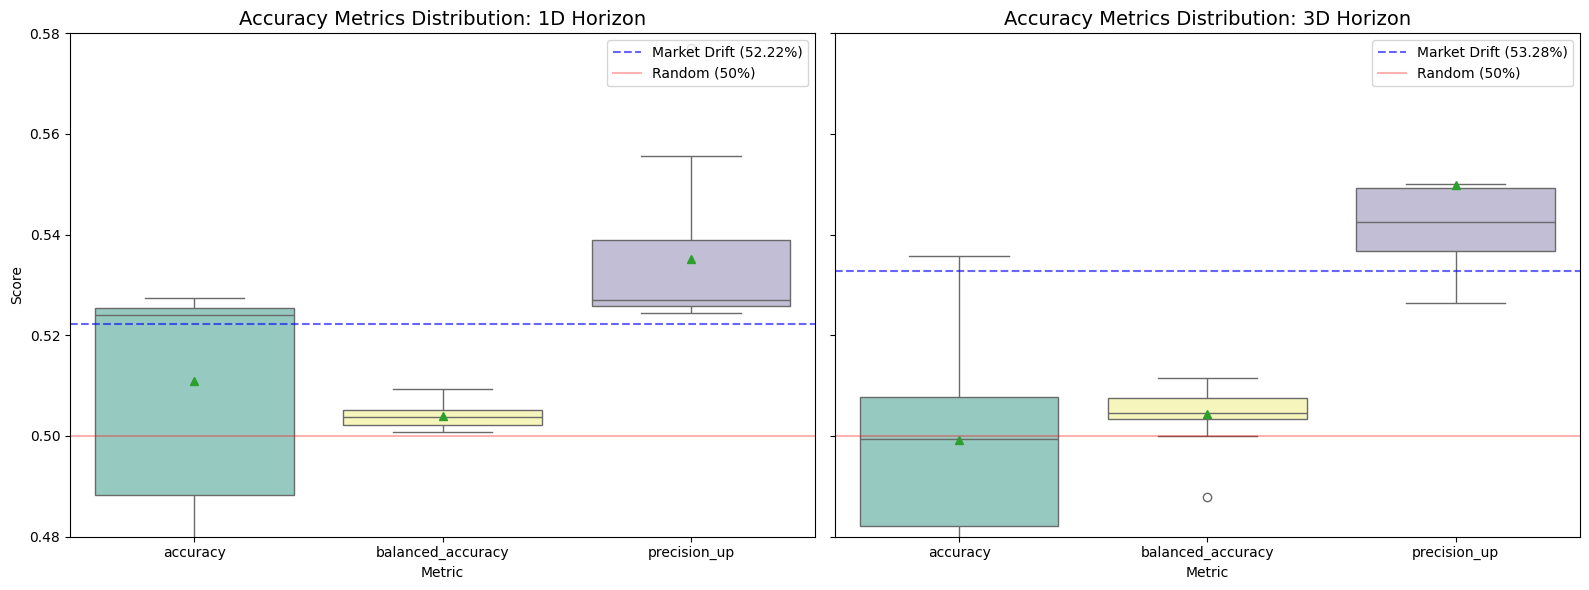

In [39]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 数据准备
acc_metrics = ['accuracy', 'balanced_accuracy', 'precision_up']
df_melted = metrics.melt(id_vars=['horizon_days', 'model'], 
                         value_vars=acc_metrics, 
                         var_name='Metric', 
                         value_name='Score')

# 2. 创建画布
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for i, h in enumerate([1, 3]):
    subset = df_melted[df_melted['horizon_days'] == h]
    sns.boxplot(ax=axes[i], data=subset, x='Metric', y='Score', palette='Set3', showmeans=True)
    
    # 提取该 Horizon 下 always_up_acc 的均值作为基准线
    base_acc = metrics[(metrics['horizon_days'] == h)]['always_up_acc'].mean()
    axes[i].axhline(base_acc, color='blue', linestyle='--', alpha=0.6, label=f'Market Drift ({base_acc:.2%})')
    axes[i].axhline(0.5, color='red', linestyle='-', alpha=0.3, label='Random (50%)')
    
    axes[i].set_title(f'Accuracy Metrics Distribution: {h}D Horizon', fontsize=14)
    axes[i].set_ylim(0.48, 0.58) # 聚焦在 50% 附近的关键区间
    axes[i].legend(loc='upper right')

plt.tight_layout()
plt.show()

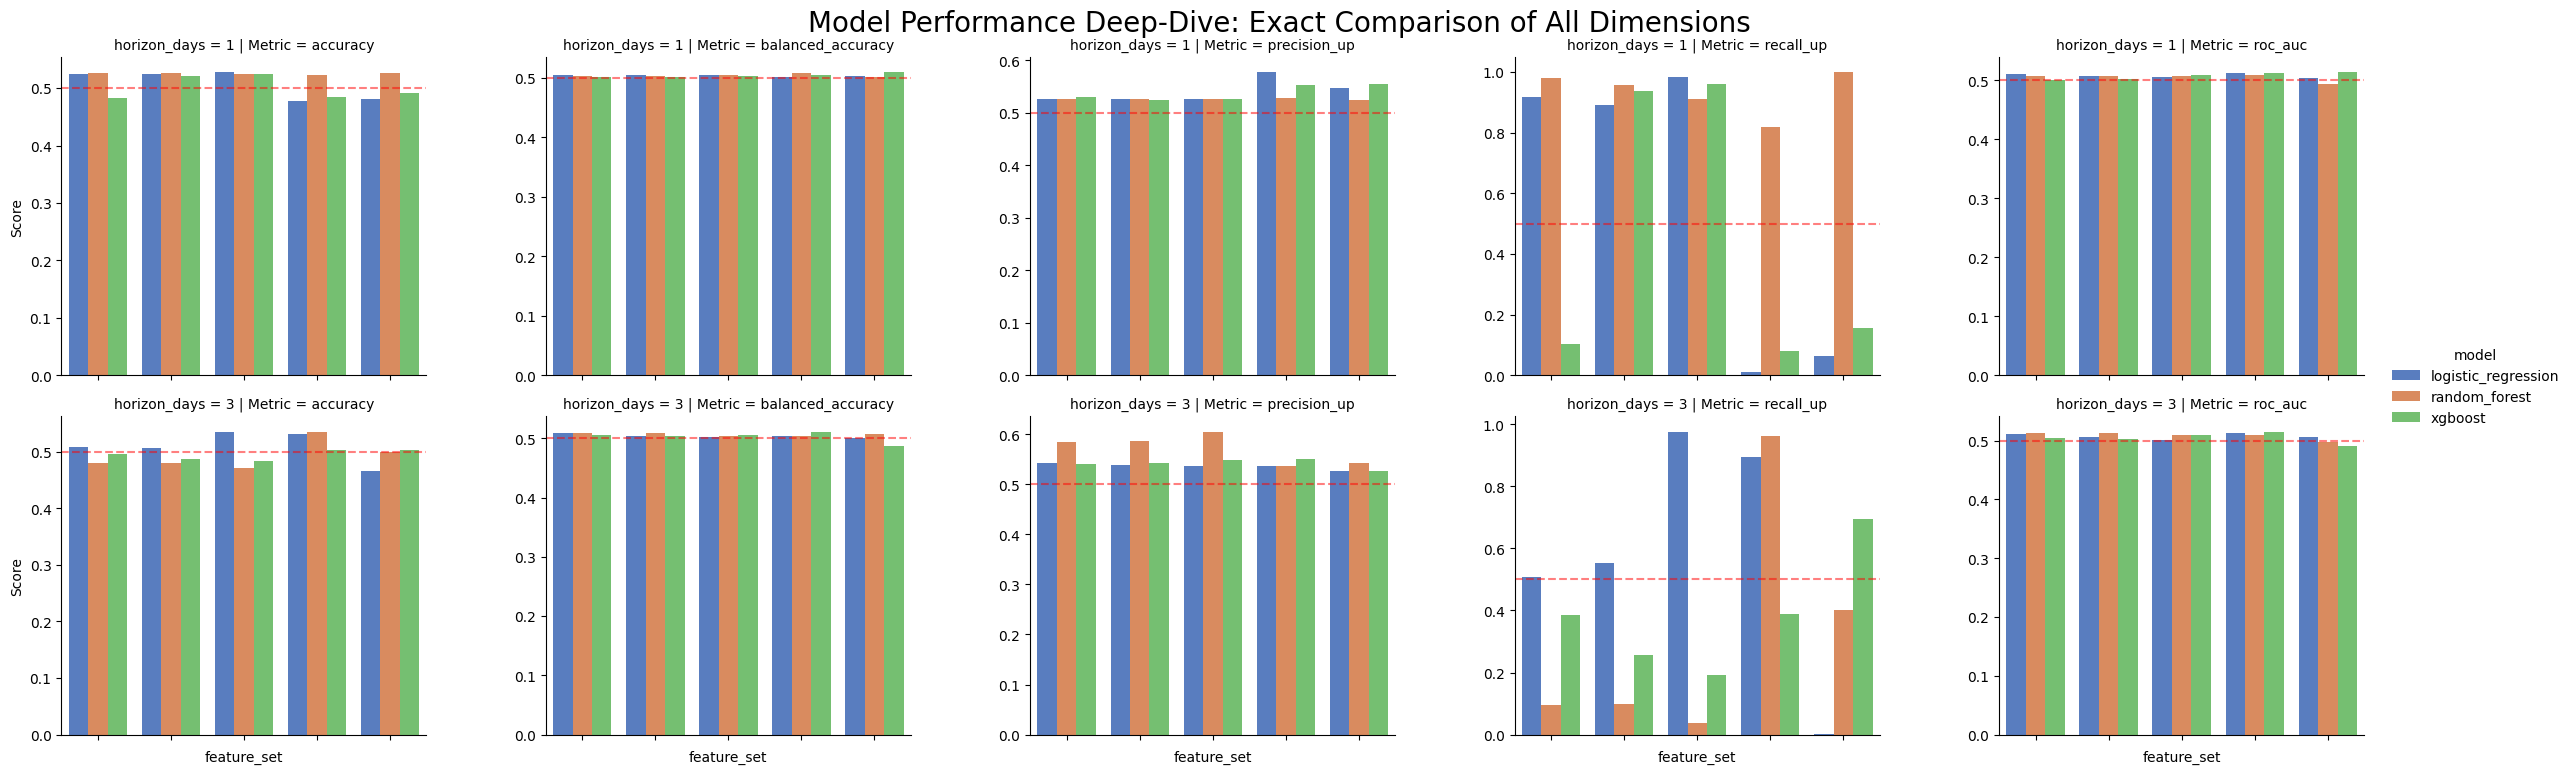

In [31]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 准备多维数据
# 包含你关心的所有评价指标
target_metrics = ['accuracy', 'balanced_accuracy', 'precision_up', 'recall_up', 'roc_auc']

df_plot = metrics.melt(
    id_vars=['feature_set', 'model', 'horizon_days'],
    value_vars=target_metrics,
    var_name='Metric',
    value_name='Score'
)

# 2. 创建分面网格图
# 行 (Row) = Horizon (1D vs 3D)
# 列 (Col) = Metric (Accuracy, ROC_AUC, etc.)
# X轴 = Feature Set
# 颜色 (Hue) = Model
g = sns.catplot(
    data=df_plot,
    x='feature_set',
    y='Score',
    hue='model',
    col='Metric',
    row='horizon_days',
    kind='bar',
    height=4,
    aspect=1.2,
    sharey=False,  # 每个指标的刻度范围不同，不强制统一 y 轴
    palette='muted'
)

# 3. 细节美化
g.set_xticklabels(rotation=45, horizontalalignment='right')
g.fig.subplots_adjust(top=0.92)
g.fig.suptitle('Model Performance Deep-Dive: Exact Comparison of All Dimensions', fontsize=20)

# 在 0.5 处增加红线（随机基准）
for ax in g.axes.flat:
    ax.axhline(0.5, color='red', linestyle='--', alpha=0.5)

plt.show()

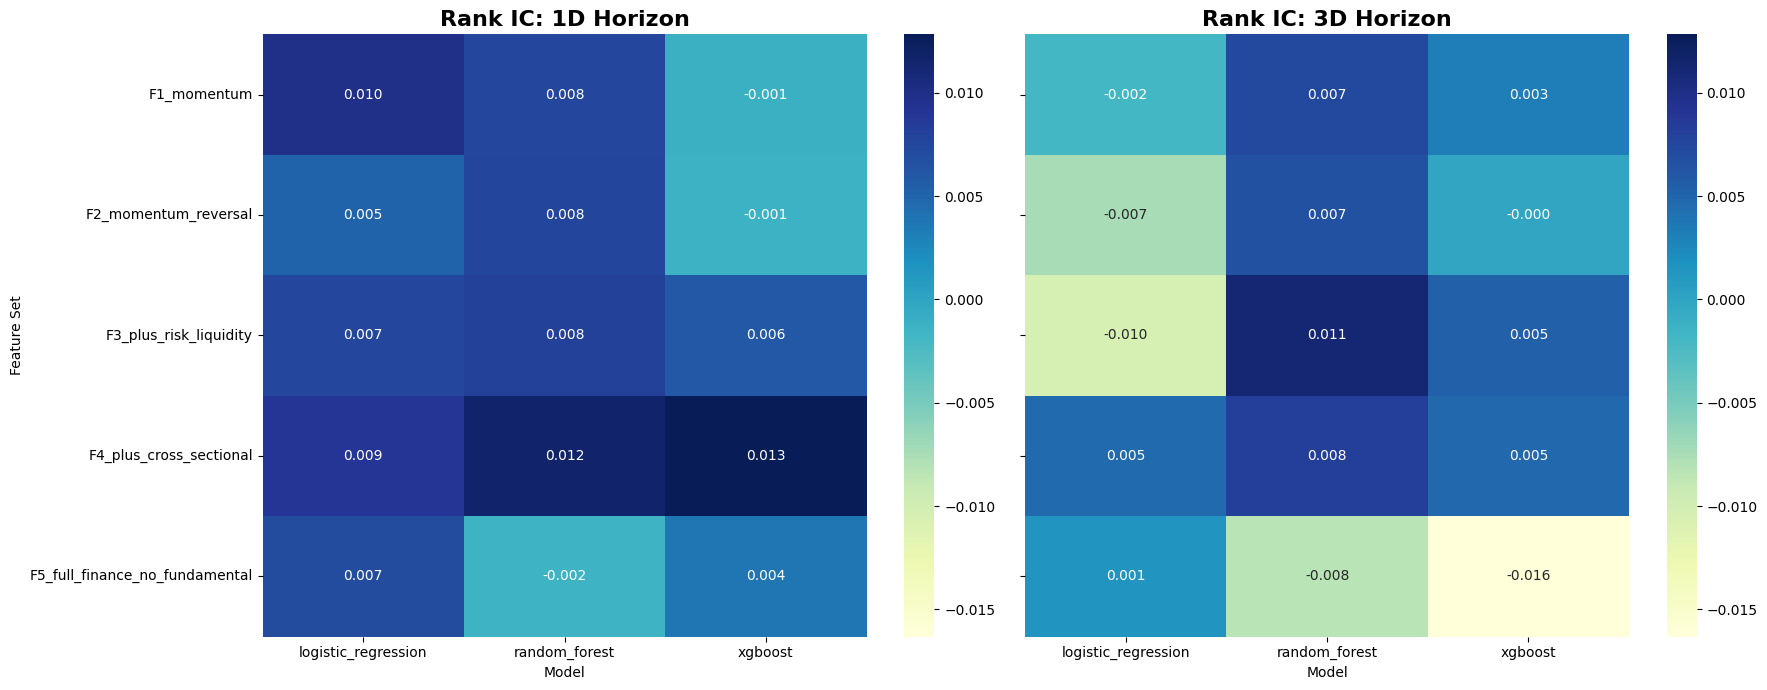

In [35]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Prepare data and figure
# Using a shared color scale (vmin/vmax) to make the comparison meaningful
vmin = metrics['rank_ic'].min()
vmax = metrics['rank_ic'].max()

fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

# 2. Plot 1D Heatmap
df_1d = metrics[metrics['horizon_days'] == 1].pivot(index='feature_set', columns='model', values='rank_ic')
sns.heatmap(df_1d, annot=True, fmt=".3f", cmap="YlGnBu", ax=axes[0], vmin=vmin, vmax=vmax)
axes[0].set_title('Rank IC: 1D Horizon', fontsize=16, fontweight='bold')
axes[0].set_ylabel('Feature Set')
axes[0].set_xlabel('Model')

# 3. Plot 3D Heatmap
df_3d = metrics[metrics['horizon_days'] == 3].pivot(index='feature_set', columns='model', values='rank_ic')
sns.heatmap(df_3d, annot=True, fmt=".3f", cmap="YlGnBu", ax=axes[1], vmin=vmin, vmax=vmax)
axes[1].set_title('Rank IC: 3D Horizon', fontsize=16, fontweight='bold')
axes[1].set_ylabel('') # Hidden for clarity as it matches the left plot
axes[1].set_xlabel('Model')

plt.tight_layout()
plt.show()

No features pass strict filter |IC1D| and |IC3D| > 0.1. Showing top 12 by joint strength instead.


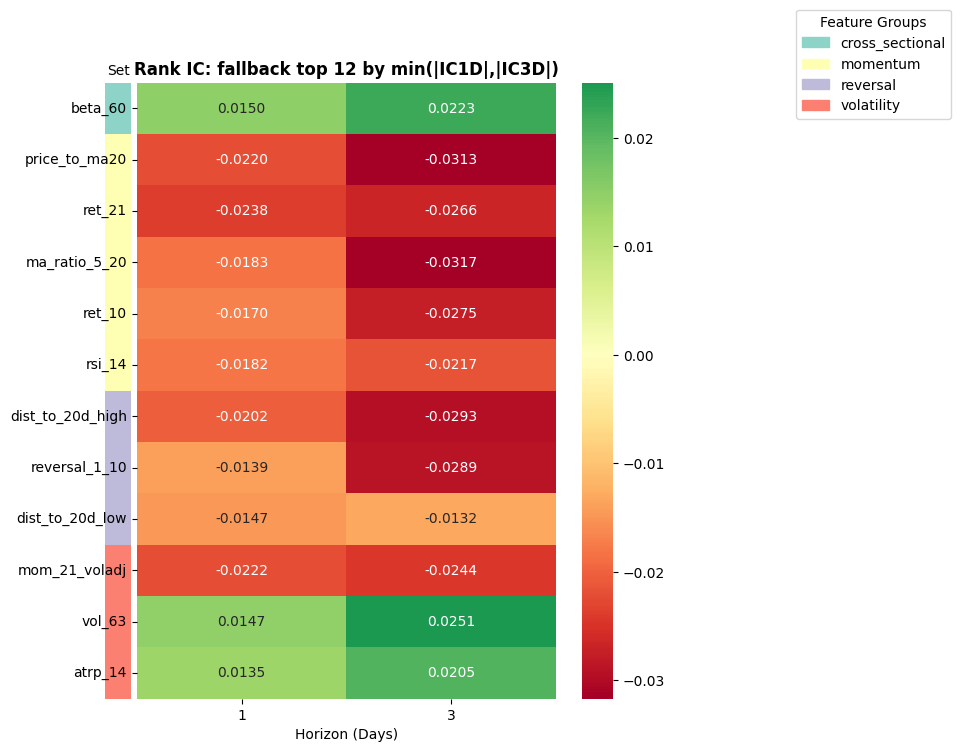

In [97]:
# IC per feature (strict filtered view for PPT)
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap

df = pd.read_csv(OUT / 'tables' / f'{TAG}_{MODE}_per_feature_ic_test.csv')
df = df.dropna(subset=['ic_mean'])

# Keep only features where BOTH 1D and 3D |IC| > threshold
IC_ABS_THRESHOLD = 0.10
FALLBACK_TOP_K = 12

pivot_all = df.pivot_table(
    index=['feature_group', 'feature'],
    columns='horizon_days',
    values='ic_mean',
    aggfunc='mean'
 )

required_horizons = [1, 3]
missing = [h for h in required_horizons if h not in pivot_all.columns]
if missing:
    raise ValueError(f"Required horizons not found in data: {missing}. Available: {list(pivot_all.columns)}")

strict_mask = (pivot_all[1].abs() > IC_ABS_THRESHOLD) & (pivot_all[3].abs() > IC_ABS_THRESHOLD)
keep_idx = pivot_all[strict_mask].index

fallback_used = False
if len(keep_idx) == 0:
    # Fallback: rank by joint strength (minimum abs(IC) across 1D/3D)
    fallback_used = True
    ranked = pivot_all.assign(min_abs_ic=pivot_all[[1, 3]].abs().min(axis=1))
    keep_idx = ranked.sort_values('min_abs_ic', ascending=False).head(FALLBACK_TOP_K).index
    print(
        f"No features pass strict filter |IC1D| and |IC3D| > {IC_ABS_THRESHOLD}. "
        f"Showing top {FALLBACK_TOP_K} by joint strength instead."
    )

df = df.set_index(['feature_group', 'feature']).loc[keep_idx].reset_index()

# Sort by group and average absolute IC strength
feature_strength = df.groupby(['feature_group', 'feature'], as_index=False).agg(
    abs_ic_mean=('ic_mean', lambda s: s.abs().mean())
)
df = df.merge(feature_strength, on=['feature_group', 'feature'], how='left')
df = df.sort_values(['feature_group', 'abs_ic_mean', 'feature'], ascending=[True, False, True])

# Build ordered heatmap table
feature_order = df['feature'].drop_duplicates()
pivot_ic = df.pivot(index='feature', columns='horizon_days', values='ic_mean').reindex(feature_order)

features_meta = df.drop_duplicates('feature')[['feature', 'feature_group']]
features_meta = features_meta.set_index('feature').reindex(feature_order)

# Group colors
unique_groups = features_meta['feature_group'].unique()
colors = sns.color_palette('Set3', len(unique_groups))
group_to_color = dict(zip(unique_groups, colors))
group_cmap = ListedColormap(colors)

# Plot
fig, (ax_group, ax_heatmap) = plt.subplots(
    1, 2, figsize=(8, 8),
    gridspec_kw={'width_ratios': [0.5, 10], 'wspace': 0.02}
 )

group_codes = features_meta['feature_group'].factorize()[0].reshape(-1, 1)
sns.heatmap(
    group_codes, cmap=group_cmap, cbar=False, ax=ax_group,
    yticklabels=False, xticklabels=[]
 )
ax_group.set_title('Set', fontsize=10)
ax_group.set_ylabel('')
ax_group.tick_params(left=False)

sns.heatmap(pivot_ic, annot=True, fmt='.4f', cmap='RdYlGn', center=0, ax=ax_heatmap)
title = 'Rank IC: only features with |IC1D|>0.1 and |IC3D|>0.1'
if fallback_used:
    title = f'Rank IC: fallback top {FALLBACK_TOP_K} by min(|IC1D|,|IC3D|)'
ax_heatmap.set_title(title, fontsize=12, fontweight='bold')
ax_heatmap.set_ylabel('')
ax_heatmap.set_xlabel('Horizon (Days)')

legend_patches = [mpatches.Patch(color=color, label=group) for group, color in group_to_color.items()]
fig.legend(handles=legend_patches, title='Feature Groups', bbox_to_anchor=(0.98, 0.98), loc='upper left')
fig.subplots_adjust(right=0.82)
plt.show()

In [88]:
import pandas as pd

# Build one table with both model metrics and backtest metrics
join_keys = ['feature_set', 'horizon_days', 'model']
df = pd.merge(metrics, summary, on=join_keys, how='inner', suffixes=('', '_bt')).copy()

# Resolve metric columns with fallback names
metric_candidates = {
    'sharpe': ['sharpe'],
    'sortino': ['sortino', 'sortino_ratio'],
    'max_drawdown': ['max_drawdown', 'max_dd'],
    'win_rate': ['win_rate', 'hit_rate'],
}

resolved = {}
for key, candidates in metric_candidates.items():
    col = next((c for c in candidates if c in df.columns), None)
    if col is None:
        raise ValueError(f"Missing column for {key}. Tried: {candidates}")
    resolved[key] = col

# Build screenshot-friendly row label and table
tbl = df[[
    'feature_set', 'model', 'horizon_days',
    resolved['sharpe'], resolved['sortino'], resolved['max_drawdown'], resolved['win_rate']
]].copy()

tbl['row'] = tbl.apply(
    lambda r: f"{r['feature_set']} | {r['model']} | {int(r['horizon_days'])}D", axis=1
)

tbl = tbl.rename(columns={
    resolved['sharpe']: 'Sharpe Ratio',
    resolved['sortino']: 'Sortino Ratio',
    resolved['max_drawdown']: 'Max Drawdown',
    resolved['win_rate']: 'Win Rate',
})

tbl = (
    tbl[['row', 'Sharpe Ratio', 'Sortino Ratio', 'Max Drawdown', 'Win Rate']]
      .sort_values(['Sharpe Ratio', 'Sortino Ratio'], ascending=False)
      .reset_index(drop=True)
 )

print('Evaluation Table (sorted by Sharpe, then Sortino)')
tbl.head(10)\
.style.format({
    'Sharpe Ratio': '{:.3f}',
    'Sortino Ratio': '{:.3f}',
    'Max Drawdown': '{:.2%}',
    'Win Rate': '{:.2%}'
}).background_gradient(cmap='Blues', subset=['Sharpe Ratio', 'Sortino Ratio'])

Evaluation Table (sorted by Sharpe, then Sortino)


,row,Sharpe Ratio,Sortino Ratio,Max Drawdown,Win Rate
0,F1_momentum | random_forest | 3D,1.180,1.529,-20.55%,54.96%
1,F2_momentum_reversal | random_forest | 3D,0.980,1.269,-22.65%,52.82%
2,F1_momentum | random_forest | 3D,0.871,1.099,-20.51%,56.15%
3,F4_plus_cross_sectional | logistic_regression | 1D,0.849,1.157,-23.66%,53.07%
4,F2_momentum_reversal | random_forest | 3D,0.741,0.936,-22.48%,54.28%
5,F1_momentum | xgboost | 3D,0.504,0.701,-27.36%,50.40%
6,F3_plus_risk_liquidity | random_forest | 3D,0.473,0.616,-19.35%,49.06%
7,F3_plus_risk_liquidity | xgboost | 3D,0.445,0.599,-26.28%,51.74%
8,F2_momentum_reversal | xgboost | 3D,0.402,0.569,-30.16%,48.79%
9,F5_full_finance_no_fundamental | logistic_regression | 1D,0.324,0.506,-18.89%,48.94%


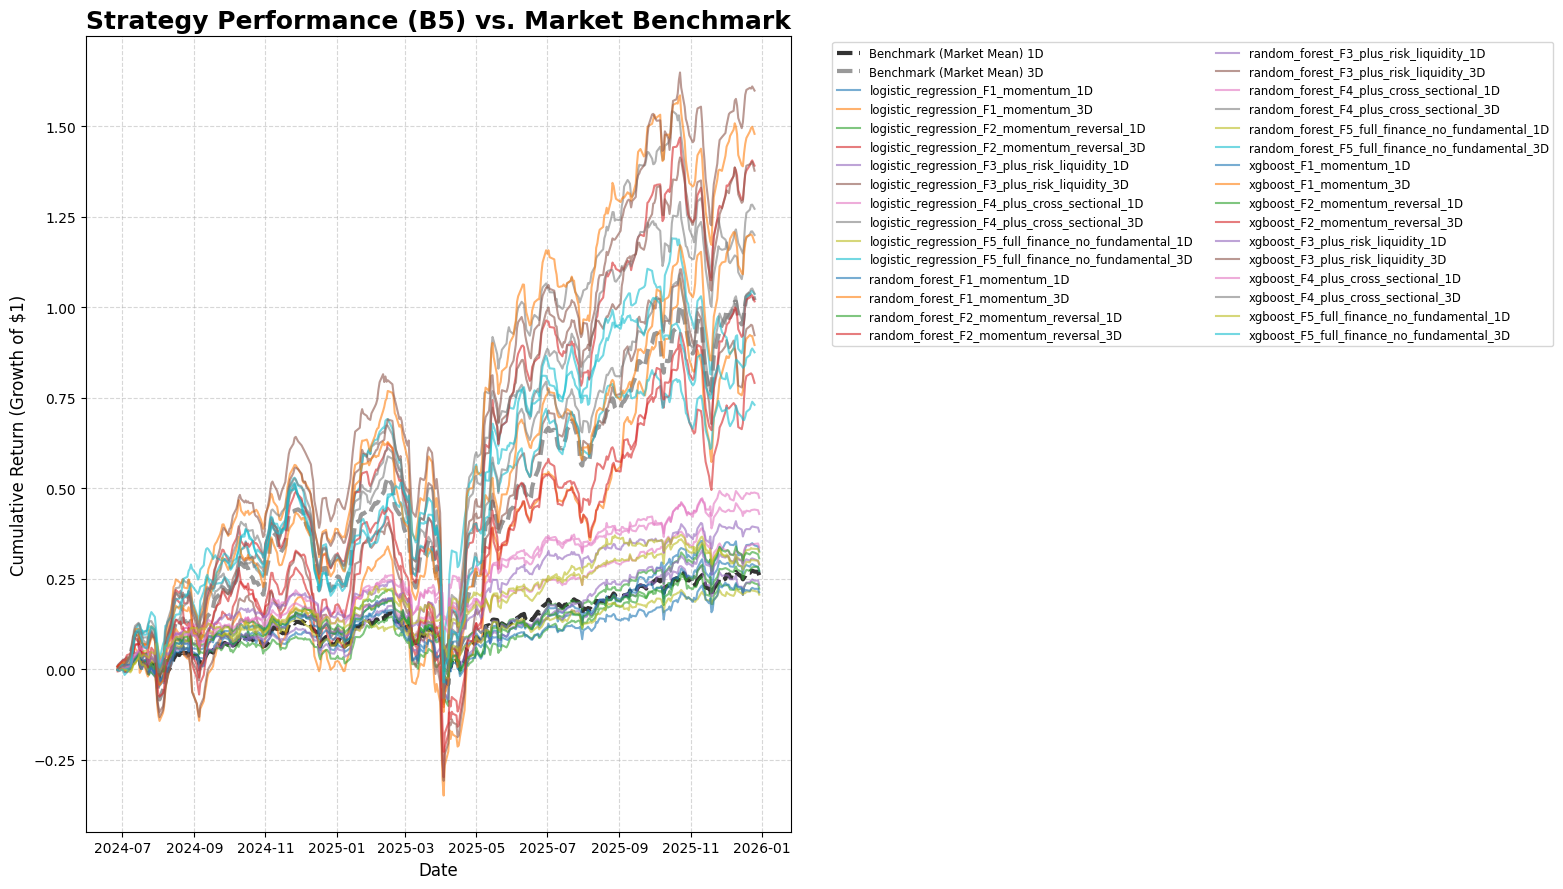

In [44]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load the data
# This file contains the daily returns for each bucket (1 to 5)

buckets_path = OUT / 'tables' / f'{TAG}_{MODE}_bucket_returns.csv'
assert buckets_path.exists(), buckets_path


buckets = pd.read_csv(buckets_path)
buckets['date'] = pd.to_datetime(buckets['date'])

# 2. Calculate the Benchmark (Market Proxy)
# We calculate the benchmark as the average return of all stocks (all buckets) 
# for each specific date and horizon. This represents the 'Market' or 'SPY' proxy.
benchmark = buckets.groupby(['date', 'horizon_days'])['avg_fwd_ret'].mean().reset_index()
benchmark.rename(columns={'avg_fwd_ret': 'ret'}, inplace=True)
benchmark = benchmark.sort_values(['horizon_days', 'date'])

# Calculate Cumulative Benchmark Return
benchmark['cum_ret'] = benchmark.groupby('horizon_days')['ret'].transform(lambda x: (1 + x).cumprod() - 1)

# 3. Calculate Strategy Performance (Top Bucket / B5)
# We filter for only the stocks the model ranked in the top 20% (Bucket 5)
strategy = buckets[buckets['bucket'] == 5].copy()
strategy = strategy.sort_values(['model', 'feature_set', 'horizon_days', 'date'])

# Calculate Cumulative Strategy Return for each combination
strategy['cum_ret'] = strategy.groupby(['model', 'feature_set', 'horizon_days'])['avg_fwd_ret'].transform(lambda x: (1 + x).cumprod() - 1)

# Create a unique label for each combination for the legend
strategy['label'] = strategy.apply(lambda r: f"{r['model']}_{r['feature_set']}_{r['horizon_days']}D", axis=1)

# 4. Plotting the single comprehensive chart
plt.figure(figsize=(16, 9))

# Plot the Benchmark lines (Dashed)
for h in [1, 3]:
    bench_sub = benchmark[benchmark['horizon_days'] == h]
    label_bench = f'Benchmark (Market Mean) {h}D'
    plt.plot(bench_sub['date'], bench_sub['cum_ret'], label=label_bench, 
             linewidth=3, linestyle='--', color='black' if h==1 else 'gray', alpha=0.8)

# Plot all Strategy lines (B5)
unique_labels = strategy['label'].unique()
colors = sns.color_palette("husl", len(unique_labels))

for i, label in enumerate(unique_labels):
    strat_sub = strategy[strategy['label'] == label]
    plt.plot(strat_sub['date'], strat_sub['cum_ret'], label=label, alpha=0.6, linewidth=1.5)

# Formatting the chart
plt.title('Strategy Performance (B5) vs. Market Benchmark', fontsize=18, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Cumulative Return (Growth of $1)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small', ncol=2)
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()

# Save and show
plt.savefig('strategy_performance_vs_benchmark.png')
plt.show()

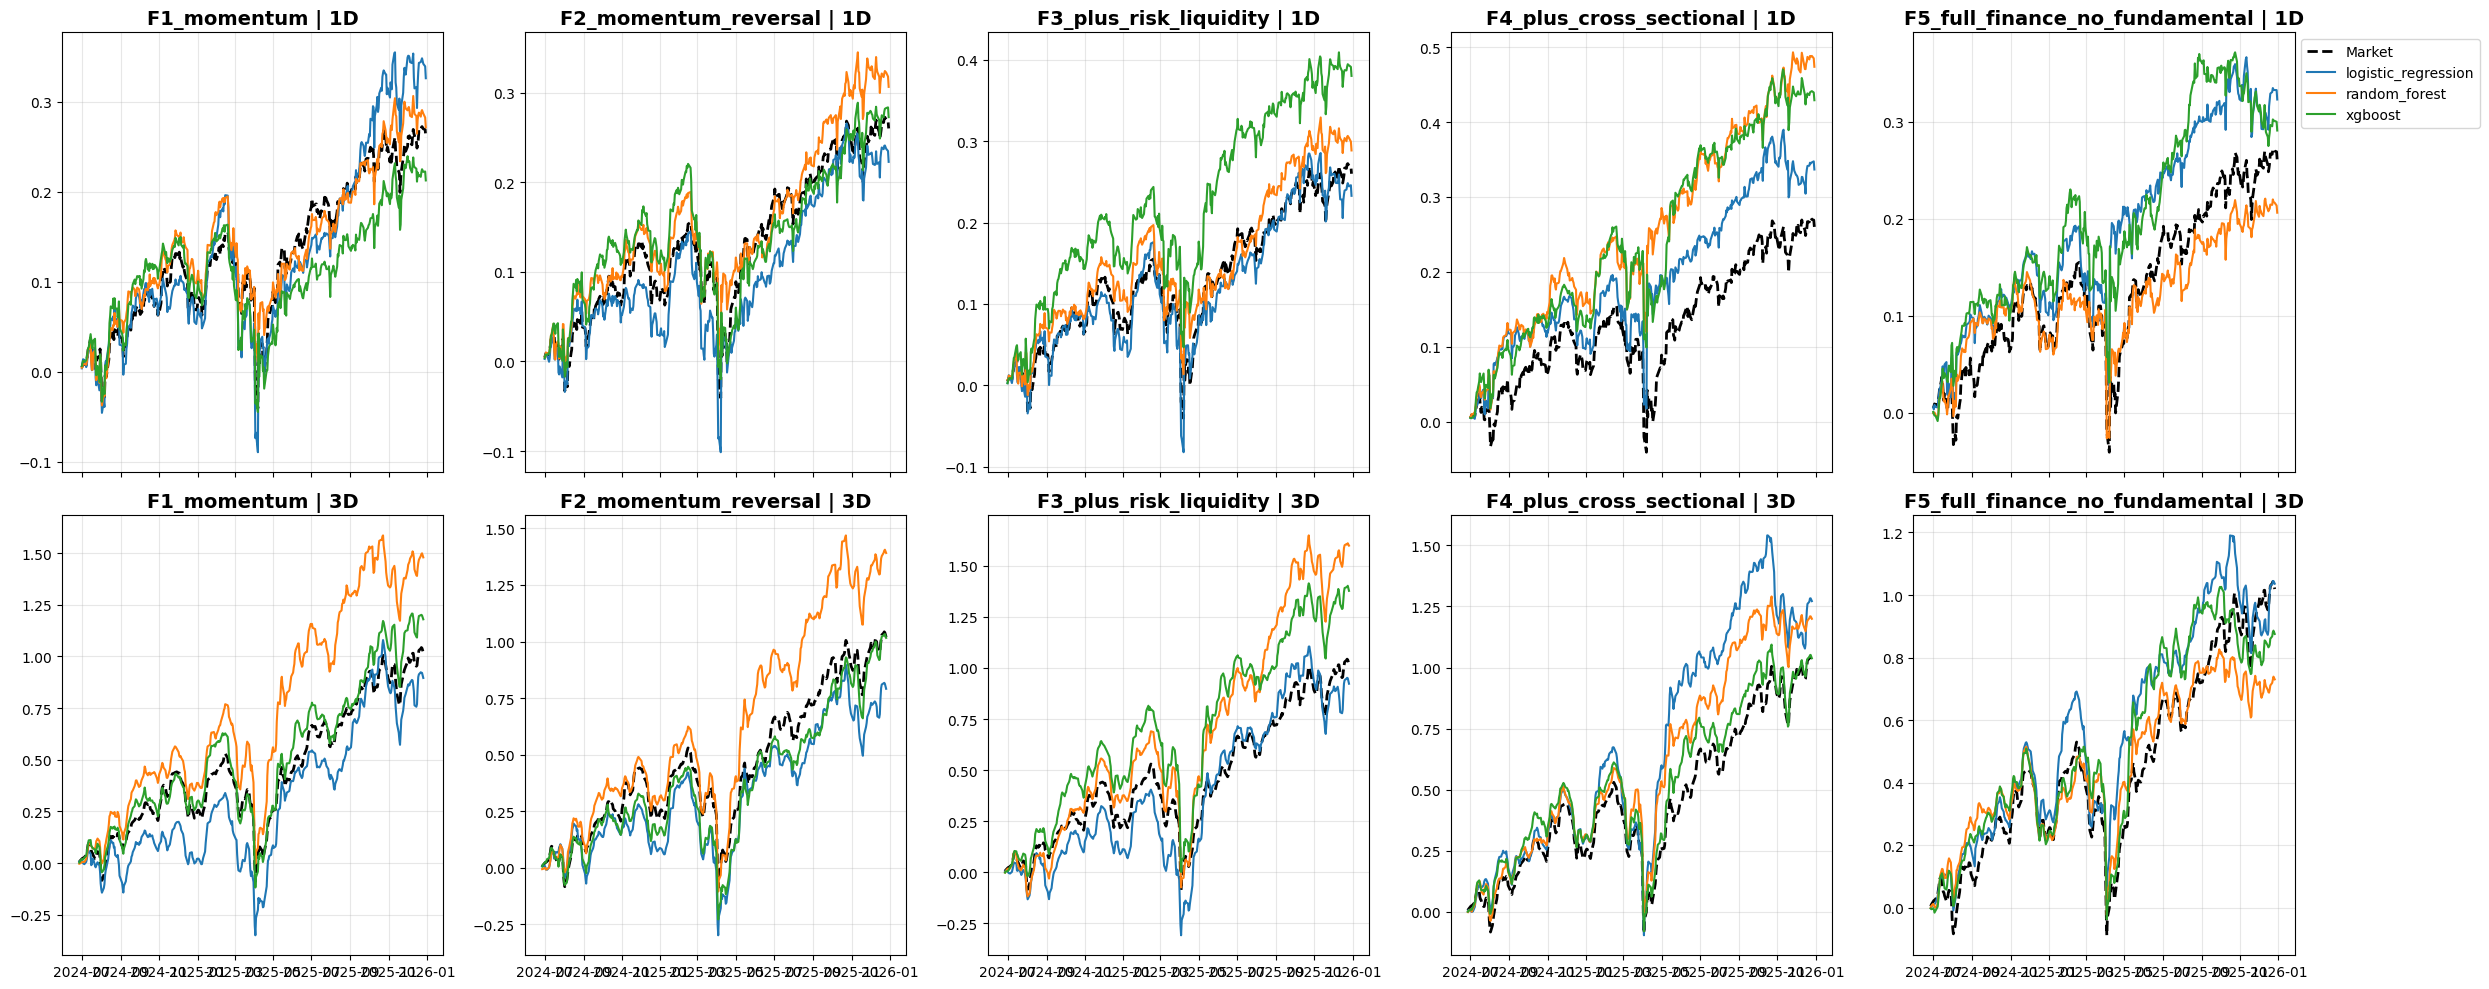

In [47]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load data

horizons = sorted(buckets['horizon_days'].unique()) # [1, 3]
feature_sets = sorted(buckets['feature_set'].unique()) # [F1...F5]

# 2. Benchmark calculation (Market Proxy)
benchmark = buckets.groupby(['date', 'horizon_days'])['avg_fwd_ret'].mean().reset_index()
benchmark.rename(columns={'avg_fwd_ret': 'bench_ret'}, inplace=True)
benchmark = benchmark.sort_values(['horizon_days', 'date'])
benchmark['cum_bench_ret'] = benchmark.groupby('horizon_days')['bench_ret'].transform(lambda x: (1 + x).cumprod() - 1)

# 3. Strategy calculation (Top Bucket / B5)
b5_rets = buckets[buckets['bucket'] == 5].copy()
b5_rets = b5_rets.sort_values(['model', 'feature_set', 'horizon_days', 'date'])
b5_rets['cum_ret'] = b5_rets.groupby(['model', 'feature_set', 'horizon_days'])['avg_fwd_ret'].transform(lambda x: (1 + x).cumprod() - 1)

# 4. Create 2x5 grid
fig, axes = plt.subplots(len(horizons), len(feature_sets), figsize=(25, 10), sharex=True)

for i, h in enumerate(horizons):
    h_bench = benchmark[benchmark['horizon_days'] == h]
    for j, fs in enumerate(feature_sets):
        ax = axes[i, j]
        
        # Plot Benchmark (SPY Proxy)
        ax.plot(h_bench['date'], h_bench['cum_bench_ret'], 
                label='Market', color='black', linestyle='--', linewidth=2)
        
        # Plot each model's B5 performance
        subset = b5_rets[(b5_rets['horizon_days'] == h) & (b5_rets['feature_set'] == fs)]
        for model in subset['model'].unique():
            m_subset = subset[subset['model'] == model]
            ax.plot(m_subset['date'], m_subset['cum_ret'], label=model)
        
        ax.set_title(f"{fs} | {h}D", fontsize=14, fontweight='bold')
        ax.grid(True, alpha=0.3)
        if i == 0 and j == len(feature_sets) - 1:
            ax.legend(loc='upper left', bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.savefig('performance_2x5_grid.png')
plt.show()

## 2) Feature sets (groups + number of features)
This table is what you want for PPT: **feature_set → feature_groups → #features**.
(We use `n_features_used` reported by the pipeline.)

In [17]:
fs_table = (metrics.groupby(['feature_set','feature_groups'], dropna=False)
                 .agg(n_features=('n_features_used','max'))
                 .reset_index()
                 .sort_values('n_features'))
fs_table

,feature_set,feature_groups,n_features
0,F1_momentum,momentum,14
1,F2_momentum_reversal,"momentum,reversal",21
2,F3_plus_risk_liquidity,"momentum,reversal,volatility,liquidity",33
3,F4_plus_cross_sectional,"momentum,reversal,volatility,liquidity,cross_s...",42
4,F5_full_finance_no_fundamental,"momentum,reversal,volatility,liquidity,cross_s...",55


### Feature set × Model grid (sanity check)

In [18]:
grid = (metrics[['feature_set','model','horizon_days']]
        .drop_duplicates()
        .sort_values(['horizon_days','feature_set','model']))
grid

,feature_set,model,horizon_days
0,F1_momentum,logistic_regression,1
1,F1_momentum,random_forest,1
2,F1_momentum,xgboost,1
3,F2_momentum_reversal,logistic_regression,1
4,F2_momentum_reversal,random_forest,1
5,F2_momentum_reversal,xgboost,1
6,F3_plus_risk_liquidity,logistic_regression,1
7,F3_plus_risk_liquidity,random_forest,1
8,F3_plus_risk_liquidity,xgboost,1
9,F4_plus_cross_sectional,logistic_regression,1
